In [69]:
from scipy import linalg as la
import numpy as np 
from modules import model_BHZ_2D as bhz
import kwant
import matplotlib.pyplot as plt
from importlib import reload
from modules import functions as fn
from modules import plotting as pl
import pickle as pi

# model

In [32]:
reload(bhz)
p = bhz.params
p['Lx'] = 10
p['Ly'] = 10
p['A'] = 1
p['B'] = 1
p['Delta'] = 2
sys = bhz.system_2D_BHZ(p)
ham = sys.finalized().hamiltonian_submatrix()


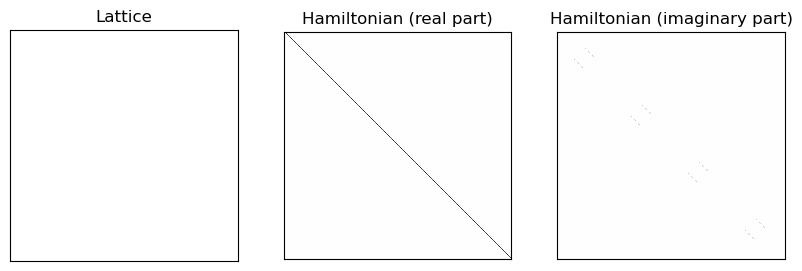

In [33]:

#### plotting ####
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[1].matshow(
    ham.real,
    cmap="bwr",
    clim=(-np.max(np.abs(ham.real)), np.max(np.abs(ham.real))),
)
ax[2].matshow(
    ham.imag,
    cmap="bwr",
    clim=(-np.max(np.abs(ham.real)), np.max(np.abs(ham.real))),
)

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

ax[0].set_title("Lattice")
ax[1].set_title("Hamiltonian (real part)")
ax[2].set_title("Hamiltonian (imaginary part)")

plt.show()

Text(0.5, 1.0, 'Energy Spectrum')

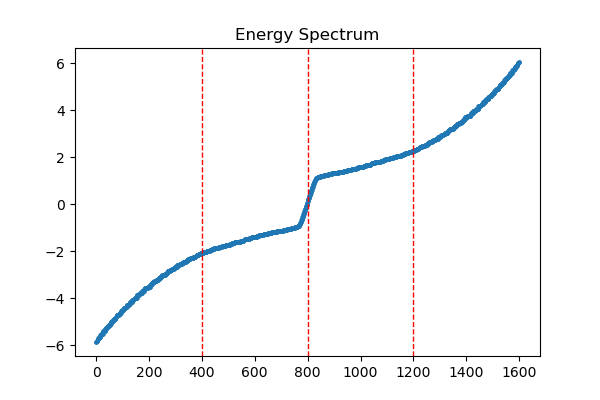

In [36]:
%matplotlib widget

from scipy import linalg as la

e, v = la.eigh(ham)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(range(len(e)), e, s=5)
ax.axvline(len(e) // 4, color="red", ls="--", linewidth=1)
ax.axvline(len(e) // 2, color="red", ls="--", linewidth=1)
ax.axvline(3 * len(e) // 4, color="red", ls="--", linewidth=1)
ax.set_title("Energy Spectrum")

# phase diagram


In [43]:



reload(bhz)
p = bhz.params
p['Lx'] = 10
p['Ly'] = 10
p['A'] = 1
p['B'] = 1
p['Delta'] =0.5


sys = bhz.system_2D_BHZ(p)
fsys = sys.finalized()


In [44]:
TR = bhz.TR_op(len(fsys.sites))


In [30]:
reload(fn)
pfaf, pfaf_list = fn.spectral_localizer_AII2D(syst=sys,W=0,E0=0,TR=TR)

E0: 0 x0,y0: -0.5 -0.5 kappa: 0.1 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Realization Pfaffian: -1.0
Pfaffian sign: -1.0


In [85]:


reload(fn)
reload(bhz)
p = bhz.params
p['Lx'] = 10
p['Ly'] = 10
p['A'] = 1
p['B'] = 1
p['Delta'] = 2

kappa_range = np.linspace(0,1.5,50)
E_range = np.linspace(-2.5,2.5,50)
sys,_ = bhz.system_2D_BHZ(Lx=10,Ly=10,params=p)
fsys = sys.finalized()

p_spec = fn.params.copy()
E_kap_dict = {}
E_kap_dict_reals = {}

for E in [0]:   
    E_kap_dict[E] = []
    E_kap_dict_reals[E] = []

    for kap in kappa_range:
        p_spec['kappa'] = kap
        locgap, locgap_list = fn.spectral_localizer_AII2D(syst=sys,W=0,E0=E,TR=TR,compute_inv=False,compute_localgap=True,p=p_spec)
        E_kap_dict[E].append(locgap)
        E_kap_dict_reals[E].append(locgap_list)

E0: 0 x0,y0: -0.5 -0.5 kappa: 0.0 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Local gap realization: [0.03579746]
Time: 0.3306370680220425
Local gap: 0.03579746345796445
E0: 0 x0,y0: -0.5 -0.5 kappa: 0.030612244897959183 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Local gap realization: [0.27440925]
Time: 0.3855516859330237
Local gap: 0.2744092477564191
E0: 0 x0,y0: -0.5 -0.5 kappa: 0.061224489795918366 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Local gap realization: [0.552461]
Time: 0.41227237740531564
Local gap: 0.5524609973921524


KeyboardInterrupt: 

In [72]:
locgap_matrix = np.zeros((len(E_range),len(kappa_range)))

for i,E in enumerate(E_range):
    elem = [elems[0] for elems in  E_kap_dict[E]]
    locgap_matrix[i,:] = elem

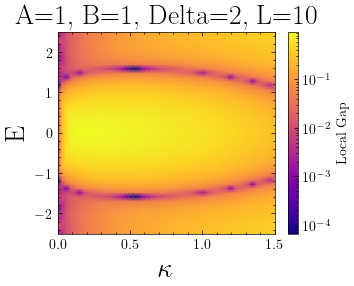

In [73]:
reload(pl)
pl.map_kappaE_locgap(kappa_range,E_range,np.abs(locgap_matrix),title='A=1, B=1, Delta=2, L=10')

In [74]:
pi.dump(E_kap_dict,open('locgap_kappaEmap_0-1.5','wb'))

In [79]:

import numpy as np

b=np.linspace(0,14,101)

E = len(b)
# for elem in b:
#     if elem not in a:
#         b.remove(elem)
# # print(b)
W = []
for i,elem in enumerate(b):
    # print(elem)
    if np.mod(i+1,E)==0:
        print('\n')
        lista = list(b[(i+1)-E:i+1])
        print(" ".join(f'{[x]}' for x in lista) )
        a = " ".join(f'"{[x]}"' for x in lista)
        W.append(a)



[0.0] [0.14] [0.28] [0.42000000000000004] [0.56] [0.7000000000000001] [0.8400000000000001] [0.9800000000000001] [1.12] [1.2600000000000002] [1.4000000000000001] [1.54] [1.6800000000000002] [1.8200000000000003] [1.9600000000000002] [2.1] [2.24] [2.3800000000000003] [2.5200000000000005] [2.66] [2.8000000000000003] [2.9400000000000004] [3.08] [3.22] [3.3600000000000003] [3.5000000000000004] [3.6400000000000006] [3.7800000000000002] [3.9200000000000004] [4.0600000000000005] [4.2] [4.340000000000001] [4.48] [4.62] [4.760000000000001] [4.9] [5.040000000000001] [5.180000000000001] [5.32] [5.460000000000001] [5.6000000000000005] [5.74] [5.880000000000001] [6.0200000000000005] [6.16] [6.300000000000001] [6.44] [6.580000000000001] [6.720000000000001] [6.86] [7.000000000000001] [7.140000000000001] [7.280000000000001] [7.420000000000001] [7.5600000000000005] [7.700000000000001] [7.840000000000001] [7.98] [8.120000000000001] [8.260000000000002] [8.4] [8.540000000000001] [8.680000000000001] [8.82]